# **Cryptocurrency Price Prediction Using Long-Short Term Memory**

---

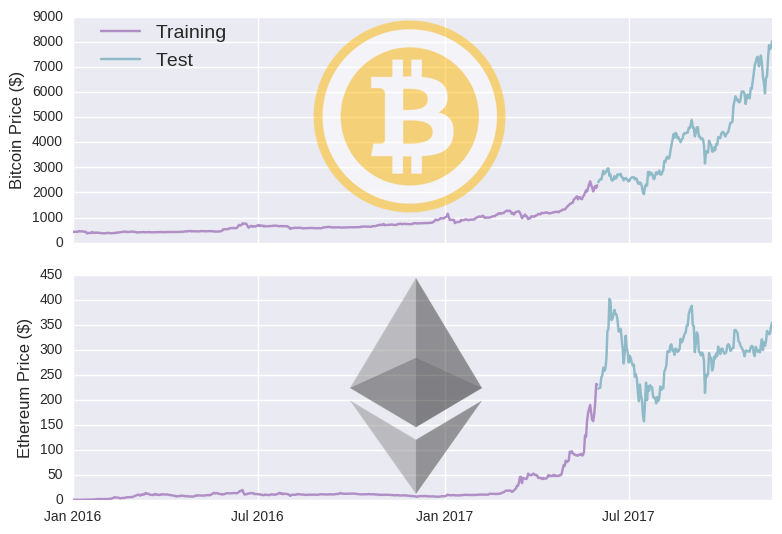


> **Cryptocurrency** is a type of online payment that may be used to buy and sell products and services. Many businesses have created their own currencies, known as tokens, that can be exchanged for the goods or services that the business offers. Consider them to be arcade tokens or casino chips. To use the good or service, you'll need to convert actual money for cryptocurrency. is the technology that enables cryptocurrency to function. is a technology that handles and records transactions across numerous computers. The security of this technology is part of its attractiveness.






> Almost 15,000 different cryptocurrencies are publicly traded, and cryptocurrencies are continuing to spread into new markets. On December 3rd, 2021, the total value of all cryptocurrencies was around 2.6 trillion dollars, down from an all-time high of **\$2.9 trillion** just weeks before. The overall market value of bitcoins, the most widely used digital money, was estimated to be around $1.1 trillion.





> Ethereum is the second largest cryptocurrency after Bitcoin. With so much hype and frenzy about cryptocurrecies several investors wish to build their wealth using this new-age technology. Similar to the stock markets, cryptocurrenices fluctuate due to a large number of factors including internet, more adoption in mainstream use, government regulations, tweets, cybersecurity attacks on several networks, etc.** Timely prediction of values** using emerging techniques like *machine learning* has enabled several investors to take advantage of the liquidity in the market and cash in more money. The biggest advantage to the market is the presence of **high volatility** leaving room for a lot of speculation and hence, prediction.

> We'll look at three of the most well-known ones in this study. As a result, the paper aims to do the following by employing machine learning algorithms that can uncover hidden patterns in data, integrate them, and generate considerably more accurate predictions: • Providing a complete examination of the many existing techniques for predicting the prices of Bitcoin, Ethereum, and (BTC, ETH, and LTC, respectively). • For prediction, a deep learning method called long short-term memory (LSTM) has been used.
The main goal is to develop a trustworthy prediction model based on historical values that investors can trust. The article also attempts to address the following research questions:
  * How can machine learning algorithms assist investors and decision-makers in predicting cryptocurrency prices?
  * 'What is the best model for predicting future cryptocurrency prices?




###**Problem Definition**

Cryptocurrencies are a highly popular asset in the modern age of the internet and are set to take center stage with the advent of Web3.0 . More and more wish to acquire such crypto assets. There are a lot of cryptocurrencies in the market currently including Ethereum, Bitcoin, Litecoin, Dogecoin, Matic Network, etc which are traded over several crypto exchanges such as Binance, Wazir and Coinbase.
One of the biggest issues with cryptocurrencies is volatility which makes it harder to track its prices. This makes it difficult for users to invest properly. They are not able to decide how many coins to buy and when. To solve this problem, we want to make a cryptocurrency price predictor which will predict the prices of 3 currencies - ETH, BTC, LTC. The model will then help us allocate different amounts of sum(buying and selling both) to different currencies depending on the amount entered by the user.

### **Possible Solution**

There are various ways to predict the prices. Some of the most popular techniques are:
1. **Regression**: It is one of the most significantly used predictive modelling techniques. Regression is used to fit a predictive model to an observed data set of values of the response and explanatory variables. Models like Logarithmic Regression are well suited as shown:

  ![picture](https://preview.redd.it/1jut7zj49vv71.png?width=408&format=png&auto=webp&s=e5999ce3422ae541a7d345b1cbb1f37242041e42)

2. **Support Vector Machines (SVM)**: SVMs are very popular for classification problems. It deals with parameters like Kernel, Hyper plane and Decision Boundary.

3. **Recurrent Neural Networks (RNN) and Long Short-Term Memory (LSTM)**: RNNs are a robust and one of the most powerful type of neural network because they support internal memory. LSTMs enable RNNs to remember inputs over a long period of time.

The performance of these techniques can be seen in this diagram:

  ![picture](https://www.researchgate.net/profile/Devrim-Uenal/publication/342692245/figure/fig9/AS:941465404469284@1601474252820/Performance-of-LSTM-SANN-SVM-and-ANN-regression-models-based-on-30-days-horizon-of.png)

Using any of these techniques, we can train our model on cryptocurrency prices of past years and then from the learning of that model, we can test and predict the present and future values of these cryptocurrencies.

In this project, we will be using the prediction technique involving RNN and LSTM as it is the most powerful one.

### **Dataset used in this Project**

We are training our pricing model, using public price data of cryptocurrencies reported from Jan 1st, 2018 to Dec 31, 2020 downloaded from Yahoo Finance. For testing our model, we use the price data of cryptocurrencies from Jan 1st 2021 to present date. We use the model to predict the crytocurrency prices for this period and compare it to the actual prices to check the efficiency of this model in predicting the prices.



### **Model we have used for prediction**

We are using a multilayer RNN Long Term Short Term Memory (LSTM) model having 3 LSTM layers with each layer followed by a dropout layer (with 20% dropout frequency) and at last have used a Dense layer to produce the predicted price.

In RNN, the information goes through a cycle. When making a decision, it considers the current input and also what it has learned from the inputs it has received previously.

The image below illustrates how the flow of information works in the RNN algorithm:
![picture](https://editor.analyticsvidhya.com/uploads/74558RNNs.png)

In an LSTM there are three gates:
1. Input Gate
2. Forget Gate
3. Output Gate

These gates determine whether or not to let new input in (input gate), delete the information because it isn’t important (forget gate), or let it impact the output at the current timestep (output gate). Below is an illustration of an RNN with its three gates:
![picture](https://editor.analyticsvidhya.com/uploads/89215LSTM.png)

The gates in an LSTM are analog in the form of sigmoids, so they also range from zero to one. This helps in backpropagation.

Thus we can train our data using this model and then predict the future prices of cryptocurrencies from the learnings of the model.


### **Problems with our approach**

The RNN-LSTM model that we have used to predict the prices of crypto currency is very accurate on the test data, however, it fails to predict the prices very accurately for the long term. We observed that the model can be used for predicting prices only for the next 5-7 days without significant loss in accuracy. That is why we have only used the model to predict the prices for the next 7 days.

### **Implementation**

In [1]:
!pip install yfinance

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_datareader as web
import datetime as dt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.models import Sequential
from sklearn.metrics import r2_score

In [14]:
import yfinance as yf
import datetime as dt

crypto_currency1 = 'BTC'
against_currency = 'INR'

start_date = dt.datetime(2018, 1, 1)
end_date = dt.datetime.now()

df_btc = yf.download(f'{crypto_currency1}-{against_currency}', start=start_date, end=end_date)

print(f"\n\nThe head of the dataframe of {crypto_currency1}: \n\n")
print(df_btc.head())

print(f"\n\n Description of the dataset of {crypto_currency1}: \n\n")
print(df_btc.describe())

/tmp/ipykernel_1378/3225908355.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_btc = yf.download(f'{crypto_currency1}-{against_currency}', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed



The head of the dataframe of BTC: 


Price              Close          High          Low         Open  \
Ticker           BTC-INR       BTC-INR      BTC-INR      BTC-INR   
Date                                                               
2018-01-01  8.696222e+05  9.007818e+05  837625.5625  900781.7500   
2018-01-02  9.506142e+05  9.799599e+05  838620.0000  867571.8750   
2018-01-03  9.652635e+05  9.896904e+05  942885.5000  950366.8125   
2018-01-04  9.889113e+05  9.978183e+05  920925.3125  969689.4375   
2018-01-05  1.103810e+06  1.121270e+06  963781.5000  981177.1250   

Price              Volume  
Ticker            BTC-INR  
Date                       
2018-01-01   655292159999  
2018-01-02  1068916782180  
2018-01-03  1071365660160  
2018-01-04  1380945947770  
2018-01-05  1509844138230  


 Description of the dataset of BTC: 


Price          Close          High           Low          Open        Volume
Ticker       BTC-INR       BTC-INR       BTC-INR       BTC-INR       BTC-I

In [15]:
import yfinance as yf
import datetime as dt

crypto_currency2 = 'ETH'
against_currency = 'INR'

start_date = dt.datetime(2018, 1, 1)
end_date = dt.datetime.now()

df_eth = yf.download(f'{crypto_currency2}-{against_currency}', start=start_date, end=end_date)

print(f"\n\nThe head of the dataframe of {crypto_currency2}: \n\n")
print(df_eth.head())

print(f"\n\n Description of the dataset of {crypto_currency2}: \n\n")
print(df_eth.describe())

/tmp/ipykernel_1378/2117815984.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_eth = yf.download(f'{crypto_currency2}-{against_currency}', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed



The head of the dataframe of ETH: 


Price              Close          High           Low          Open  \
Ticker           ETH-INR       ETH-INR       ETH-INR       ETH-INR   
Date                                                                 
2018-01-01  49197.914062  49827.601562  47362.117188  48239.968750   
2018-01-02  56117.968750  58251.800781  49179.132812  49179.132812   
2018-01-03  61132.718750  61878.910156  55161.835938  56216.699219   
2018-01-04  62185.550781  66252.843750  60014.964844  61068.777344   
2018-01-05  63185.605469  68104.453125  60564.062500  61857.671875   

Price             Volume  
Ticker           ETH-INR  
Date                      
2018-01-01  165285026150  
2018-01-02  366953542271  
2018-01-03  323415655935  
2018-01-04  412248795500  
2018-01-05  423243878353  


 Description of the dataset of ETH: 


Price           Close           High            Low           Open  \
Ticker        ETH-INR        ETH-INR        ETH-INR        ETH-INR   
cou

In [16]:
import yfinance as yf
import datetime as dt

crypto_currency3 = 'LTC'
against_currency = 'INR'

start_date = dt.datetime(2018, 1, 1)
end_date = dt.datetime.now()

df_ltc = yf.download(f'{crypto_currency3}-{against_currency}', start=start_date, end=end_date)

print(f"\n\nThe head of the dataframe of {crypto_currency3}: \n\n")
print(df_ltc.head())

print(f"\n\n Description of the dataset of {crypto_currency3}: \n\n")
print(df_ltc.describe())

/tmp/ipykernel_1378/1418073395.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_ltc = yf.download(f'{crypto_currency3}-{against_currency}', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed



The head of the dataframe of LTC: 


Price              Close          High           Low          Open  \
Ticker           LTC-INR       LTC-INR       LTC-INR       LTC-INR   
Date                                                                 
2018-01-01  14583.676758  15066.487305  14183.217773  14787.241211   
2018-01-02  16223.150391  16737.550781  14580.938477  14580.938477   
2018-01-03  15580.868164  16544.080078  15439.072266  16223.848633   
2018-01-04  15301.650391  15587.663086  14397.164062  15587.663086   
2018-01-05  15786.332031  16234.661133  15080.403320  15280.350586   

Price             Volume  
Ticker           LTC-INR  
Date                      
2018-01-01   40315317869  
2018-01-02   78547924454  
2018-01-03  204170288128  
2018-01-04  220712867322  
2018-01-05  108332293947  


 Description of the dataset of LTC: 


Price          Close          High           Low          Open        Volume
Ticker       LTC-INR       LTC-INR       LTC-INR       LTC-INR    

/tmp/ipykernel_1378/4175156560.py:31: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(f'{crypto_currency}-{against_currency}', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1378/4175156560.py:72: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_test = yf.download(f'{crypto_currency}-{against_currency}', start=test_start, end=test_end)




The head of the dataframe of BTC: 


Price              Close          High          Low         Open  \
Ticker           BTC-INR       BTC-INR      BTC-INR      BTC-INR   
Date                                                               
2018-01-01  8.696222e+05  9.007818e+05  837625.5625  900781.7500   
2018-01-02  9.506142e+05  9.799599e+05  838620.0000  867571.8750   
2018-01-03  9.652635e+05  9.896904e+05  942885.5000  950366.8125   
2018-01-04  9.889113e+05  9.978183e+05  920925.3125  969689.4375   
2018-01-05  1.103810e+06  1.121270e+06  963781.5000  981177.1250   

Price              Volume  
Ticker            BTC-INR  
Date                       
2018-01-01   655292159999  
2018-01-02  1068916782180  
2018-01-03  1071365660160  
2018-01-04  1380945947770  
2018-01-05  1509844138230  


 Description of the dataset of BTC: 


Price          Close          High           Low          Open        Volume
Ticker       BTC-INR       BTC-INR       BTC-INR       BTC-INR       BTC-I

[*********************100%***********************]  1 of 1 completed



 The number of samples in our testing data = 1911


Epoch 1/25



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


93/93 ━━━━━━━━━━━━━━━━━━━━ 13s 75ms/step - loss: 0.0112
Epoch 2/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.0023
Epoch 3/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - loss: 0.0018
Epoch 4/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - loss: 0.0018
Epoch 5/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.0018
Epoch 6/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - loss: 0.0017
Epoch 7/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.0016
Epoch 8/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - loss: 0.0016
Epoch 9/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - loss: 0.0016
Epoch 10/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - loss: 0.0015
Epoch 11/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - loss: 0.0015
Epoch 12/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.0015
Epoch 13/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - loss: 0.0014
Epoch 14/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - loss: 0.0019
Epoch 15/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - loss: 0.0012
Epoch 16/25

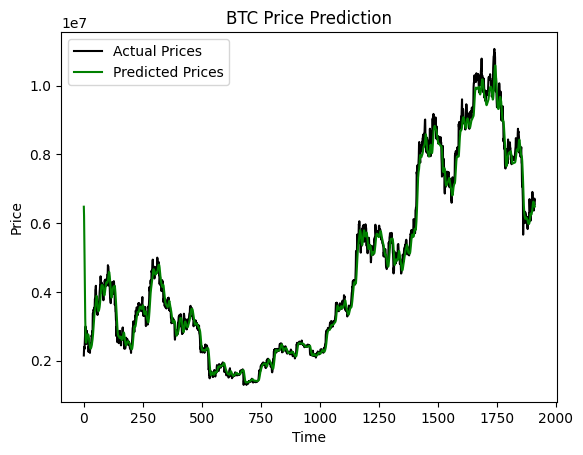

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


/tmp/ipykernel_1378/4175156560.py:133: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  final_prediction_prices = np.row_stack((final_prediction_prices, prediction))


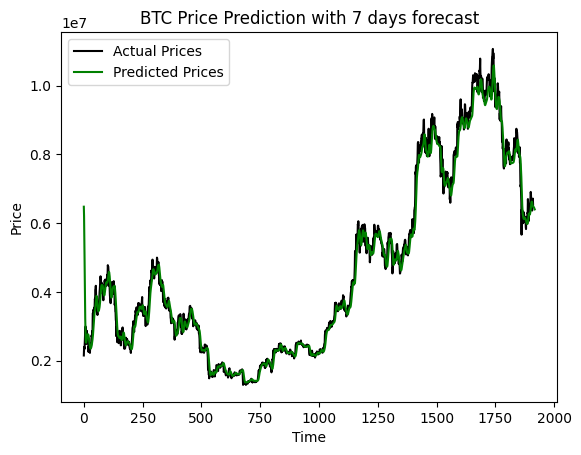

/tmp/ipykernel_1378/4175156560.py:31: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(f'{crypto_currency}-{against_currency}', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1378/4175156560.py:72: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_test = yf.download(f'{crypto_currency}-{against_currency}', start=test_start, end=test_end)




The head of the dataframe of ETH: 


Price              Close          High           Low          Open  \
Ticker           ETH-INR       ETH-INR       ETH-INR       ETH-INR   
Date                                                                 
2018-01-01  49197.914062  49827.601562  47362.117188  48239.968750   
2018-01-02  56117.968750  58251.800781  49179.132812  49179.132812   
2018-01-03  61132.718750  61878.910156  55161.835938  56216.699219   
2018-01-04  62185.550781  66252.843750  60014.964844  61068.777344   
2018-01-05  63185.605469  68104.453125  60564.062500  61857.671875   

Price             Volume  
Ticker           ETH-INR  
Date                      
2018-01-01  165285026150  
2018-01-02  366953542271  
2018-01-03  323415655935  
2018-01-04  412248795500  
2018-01-05  423243878353  


 Description of the dataset of ETH: 


Price           Close           High            Low           Open  \
Ticker        ETH-INR        ETH-INR        ETH-INR        ETH-INR   
cou

[*********************100%***********************]  1 of 1 completed



 The number of samples in our testing data = 1911


Epoch 1/25



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


93/93 ━━━━━━━━━━━━━━━━━━━━ 13s 91ms/step - loss: 0.0116
Epoch 2/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - loss: 0.0037
Epoch 3/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - loss: 0.0032
Epoch 4/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - loss: 0.0030
Epoch 5/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - loss: 0.0028
Epoch 6/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.0025
Epoch 7/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - loss: 0.0025
Epoch 8/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - loss: 0.0025
Epoch 9/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 11s 85ms/step - loss: 0.0021
Epoch 10/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 11s 91ms/step - loss: 0.0019
Epoch 11/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - loss: 0.0022
Epoch 12/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 0.0018
Epoch 13/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 11s 92ms/step - loss: 0.0020
Epoch 14/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - loss: 0.0019
Epoch 15/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.0017
Epoch 16/2

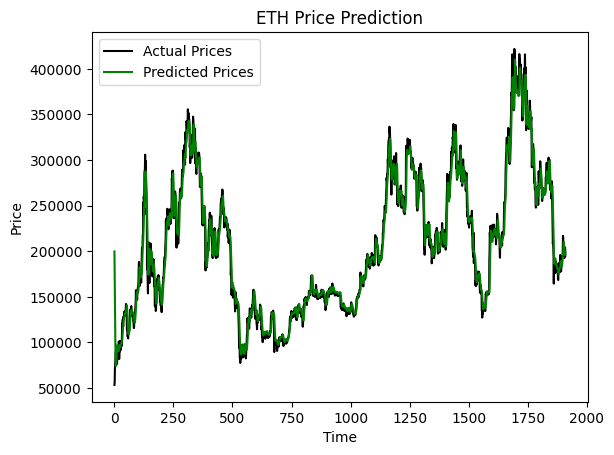

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


/tmp/ipykernel_1378/4175156560.py:133: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  final_prediction_prices = np.row_stack((final_prediction_prices, prediction))


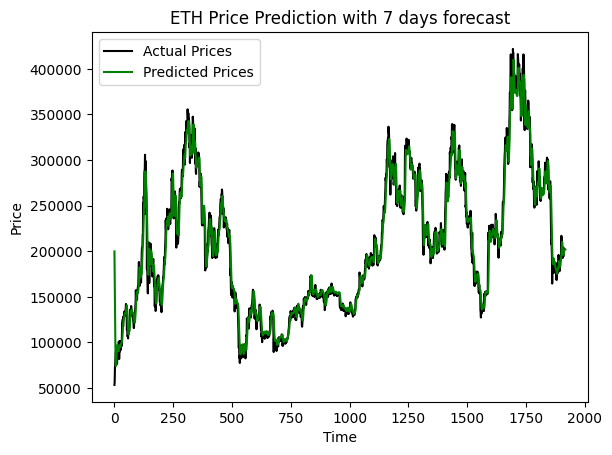

/tmp/ipykernel_1378/4175156560.py:31: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(f'{crypto_currency}-{against_currency}', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1378/4175156560.py:72: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_test = yf.download(f'{crypto_currency}-{against_currency}', start=test_start, end=test_end)




The head of the dataframe of LTC: 


Price              Close          High           Low          Open  \
Ticker           LTC-INR       LTC-INR       LTC-INR       LTC-INR   
Date                                                                 
2018-01-01  14583.676758  15066.487305  14183.217773  14787.241211   
2018-01-02  16223.150391  16737.550781  14580.938477  14580.938477   
2018-01-03  15580.868164  16544.080078  15439.072266  16223.848633   
2018-01-04  15301.650391  15587.663086  14397.164062  15587.663086   
2018-01-05  15786.332031  16234.661133  15080.403320  15280.350586   

Price             Volume  
Ticker           LTC-INR  
Date                      
2018-01-01   40315317869  
2018-01-02   78547924454  
2018-01-03  204170288128  
2018-01-04  220712867322  
2018-01-05  108332293947  


 Description of the dataset of LTC: 


Price          Close          High           Low          Open        Volume
Ticker       LTC-INR       LTC-INR       LTC-INR       LTC-INR    

[*********************100%***********************]  1 of 1 completed



 The number of samples in our testing data = 1911


Epoch 1/25



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


93/93 ━━━━━━━━━━━━━━━━━━━━ 13s 92ms/step - loss: 0.0043
Epoch 2/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - loss: 0.0022
Epoch 3/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - loss: 0.0016
Epoch 4/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - loss: 0.0017
Epoch 5/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.0015
Epoch 6/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0013
Epoch 7/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - loss: 0.0011
Epoch 8/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - loss: 0.0010
Epoch 9/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - loss: 0.0011
Epoch 10/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.0010
Epoch 11/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 9.9356e-04
Epoch 12/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 8.5198e-04
Epoch 13/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 11s 92ms/step - loss: 8.2752e-04
Epoch 14/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 9.0411e-04
Epoch 15/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 8

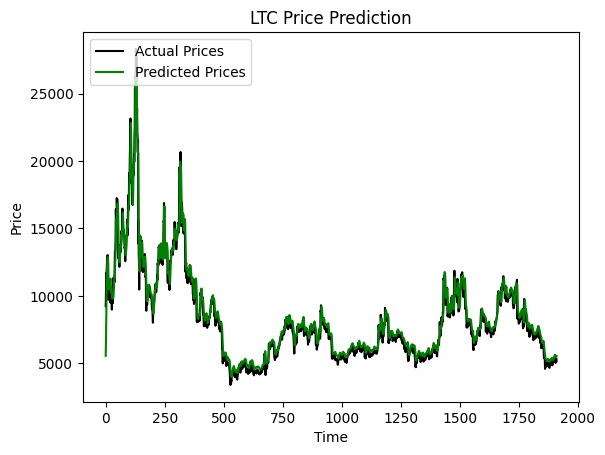

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


/tmp/ipykernel_1378/4175156560.py:133: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  final_prediction_prices = np.row_stack((final_prediction_prices, prediction))


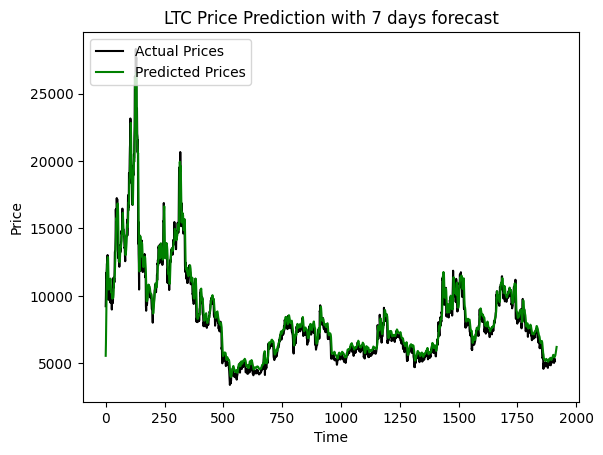

In [24]:
import yfinance as yf
import datetime as dt

crypto_currency1 = 'BTC'
crypto_currency2 = 'ETH'
crypto_currency3 = 'LTC'

against_currency = 'INR'

acc = []

def create_and_fit__model(x_train, y_train):
  model = Sequential()
  model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
  model.add(Dropout(0.2))
  model.add(LSTM(units=50, return_sequences=True))
  model.add(Dropout(0.2))
  model.add(LSTM(units=50))
  model.add(Dropout(0.2))
  model.add(Dense(units=1))

  model.compile(optimizer='adam', loss='mean_squared_error')
  model.fit(x_train, y_train, epochs=25, batch_size=32)

  return model

def prediction_function(crypto_currency):
  start_date = dt.datetime(2018, 1, 1)
  end_date = dt.datetime.now()

  df = yf.download(f'{crypto_currency}-{against_currency}', start=start_date, end=end_date)

  print(f"\n\nThe head of the dataframe of {crypto_currency}: \n\n")
  print(df.head())

  print(f"\n\n Description of the dataset of {crypto_currency}: \n\n")
  print(df.describe())

  scaler = MinMaxScaler(feature_range=(0, 1))

  df_scaled = scaler.fit_transform(df[['Close', 'Volume']].values.reshape(-1, 2))

  lookback = 60


  x_train, y_train, vol, = [], [], []

  for i in range(lookback, len(df_scaled)):

      com_vol = 0
      for j in range(i - lookback, i):
          com_vol += df_scaled[j, 1]

      com_vol = com_vol / 60
      vol.append(com_vol)

      x_train.append(df_scaled[i - lookback: i, 0])

      y_train.append(df_scaled[i, 0])


  x_train = np.array(x_train)
  y_train = np.array(y_train)
  vol = np.array(vol)

  print("\n\n The number of samples in our training data = " + str(len(x_train)) + "\n\n")

  test_start = dt.datetime(2021, 1, 1)
  test_end = dt.datetime.now()


  df_test = yf.download(f'{crypto_currency}-{against_currency}', start=test_start, end=test_end)

  actual_prices = df_test['Close'].values

  df_total = pd.concat((df['Close'], df_test['Close']), axis=0)


  model_inputs = df_total[len(df_total) - len(df_test) - lookback:].values
  model_inputs = model_inputs.reshape(-1, 1)
  model_inputs = scaler.fit_transform(model_inputs)


  x_test, y_test = [], []

  for i in range(lookback, len(model_inputs)):
      x_test.append(model_inputs[i - lookback: i, 0])
      y_test.append(model_inputs[i, 0])

  x_test = np.array(x_test)
  x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

  print("\n\n The number of samples in our testing data = " + str(len(x_test)) + "\n\n")
  x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

  model = create_and_fit__model(x_train, y_train)

  prediction_prices = model.predict(x_test)
  prediction_prices = scaler.inverse_transform(prediction_prices)

  acc.append(r2_score(actual_prices, prediction_prices))

  plt.plot(actual_prices, color='black', label='Actual Prices')
  plt.plot(prediction_prices, color='green', label='Predicted Prices')
  plt.title("{} Price Prediction".format(crypto_currency))
  plt.xlabel("Time")
  plt.ylabel("Price")
  plt.legend(loc='upper left')
  plt.show()

  real_data = [model_inputs[len(model_inputs) - lookback:len(model_inputs) + 1, 0]]
  real_data = np.array(real_data)

  prediction = []

  for i in range(7):
      rd = np.reshape(real_data, (real_data.shape[0], real_data.shape[1], 1))
      t = model.predict(rd)
      price = scaler.inverse_transform(t)
      prediction.append(price[0][0])
      n_real_data = []
      for i in range(1, len(real_data[0])):
          n_real_data.append([real_data[0][i]])
      n_real_data.append(t[0])
      n_real_data = np.array(n_real_data)
      n_real_data = np.transpose(n_real_data)
      real_data = n_real_data

  prediction = np.array(prediction)
  prediction = np.reshape(prediction, (len(prediction), 1))

  final_prediction_prices = prediction_prices
  final_prediction_prices = np.row_stack((final_prediction_prices, prediction))

  plt.plot(actual_prices, color='black', label='Actual Prices')
  plt.plot(final_prediction_prices, color='green', label='Predicted Prices')
  plt.title("{} Price Prediction with 7 days forecast".format(crypto_currency))
  plt.xlabel("Time")
  plt.ylabel("Price")
  plt.legend(loc='upper left')
  plt.show()

  price_today = actual_prices[len(actual_prices)-1]
  pred_price_today = prediction_prices[len(prediction_prices)-1][0]

  max_price = prediction[0][0]
  min_price = prediction[0][0]
  for i in range(len(prediction)):
    max_price = max(max_price, prediction[i][0])
    min_price = min(min_price, prediction[i][0])

  upside = (((max_price - pred_price_today)*100)/pred_price_today)
  downside = (((min_price - pred_price_today)*100)/pred_price_today)

  return [upside, downside], actual_prices, prediction_prices, final_prediction_prices

sides1, actual_prices_btc, prediction_prices_btc, final_prediction_prices_btc = prediction_function(crypto_currency1)
sides2, actual_prices_eth, prediction_prices_eth, final_prediction_prices_eth = prediction_function(crypto_currency2)
sides3, actual_prices_ltc, prediction_prices_ltc, final_prediction_prices_ltc = prediction_function(crypto_currency3)


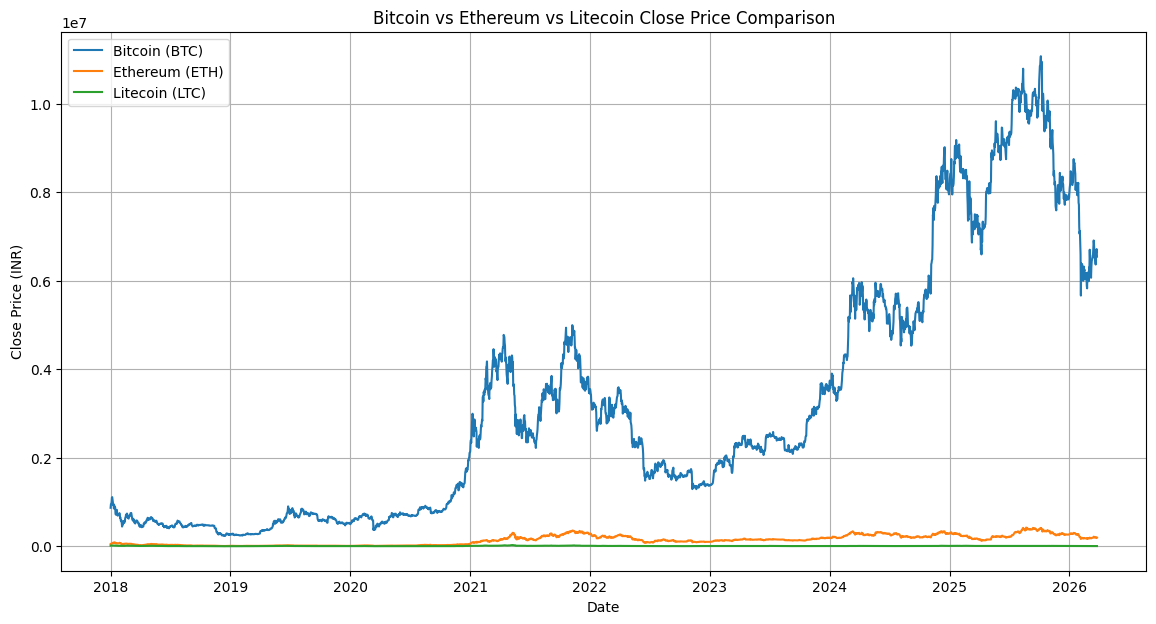

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(df_btc['Close'], label='Bitcoin (BTC)')
plt.plot(df_eth['Close'], label='Ethereum (ETH)')
plt.plot(df_ltc['Close'], label='Litecoin (LTC)')
plt.title('Bitcoin vs Ethereum vs Litecoin Close Price Comparison')
plt.xlabel('Date')
plt.ylabel('Close Price (INR)')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
print("The R2 accuracy score for BTC = {} %".format(acc[0]*100))
print("The R2 accuracy score for ETH = {} %".format(acc[1]*100))
print("The R2 accuracy score for LTC = {} %".format(acc[2]*100))

print("Average R2 accuracy score = {} %".format((acc[0]+acc[1]+acc[2])*100/3))

The R2 accuracy score for BTC = 98.65866358598329 %
The R2 accuracy score for ETH = 97.1770171175191 %
The R2 accuracy score for LTC = 96.42717326271205 %
Average R2 accuracy score = 97.42095132207147 %


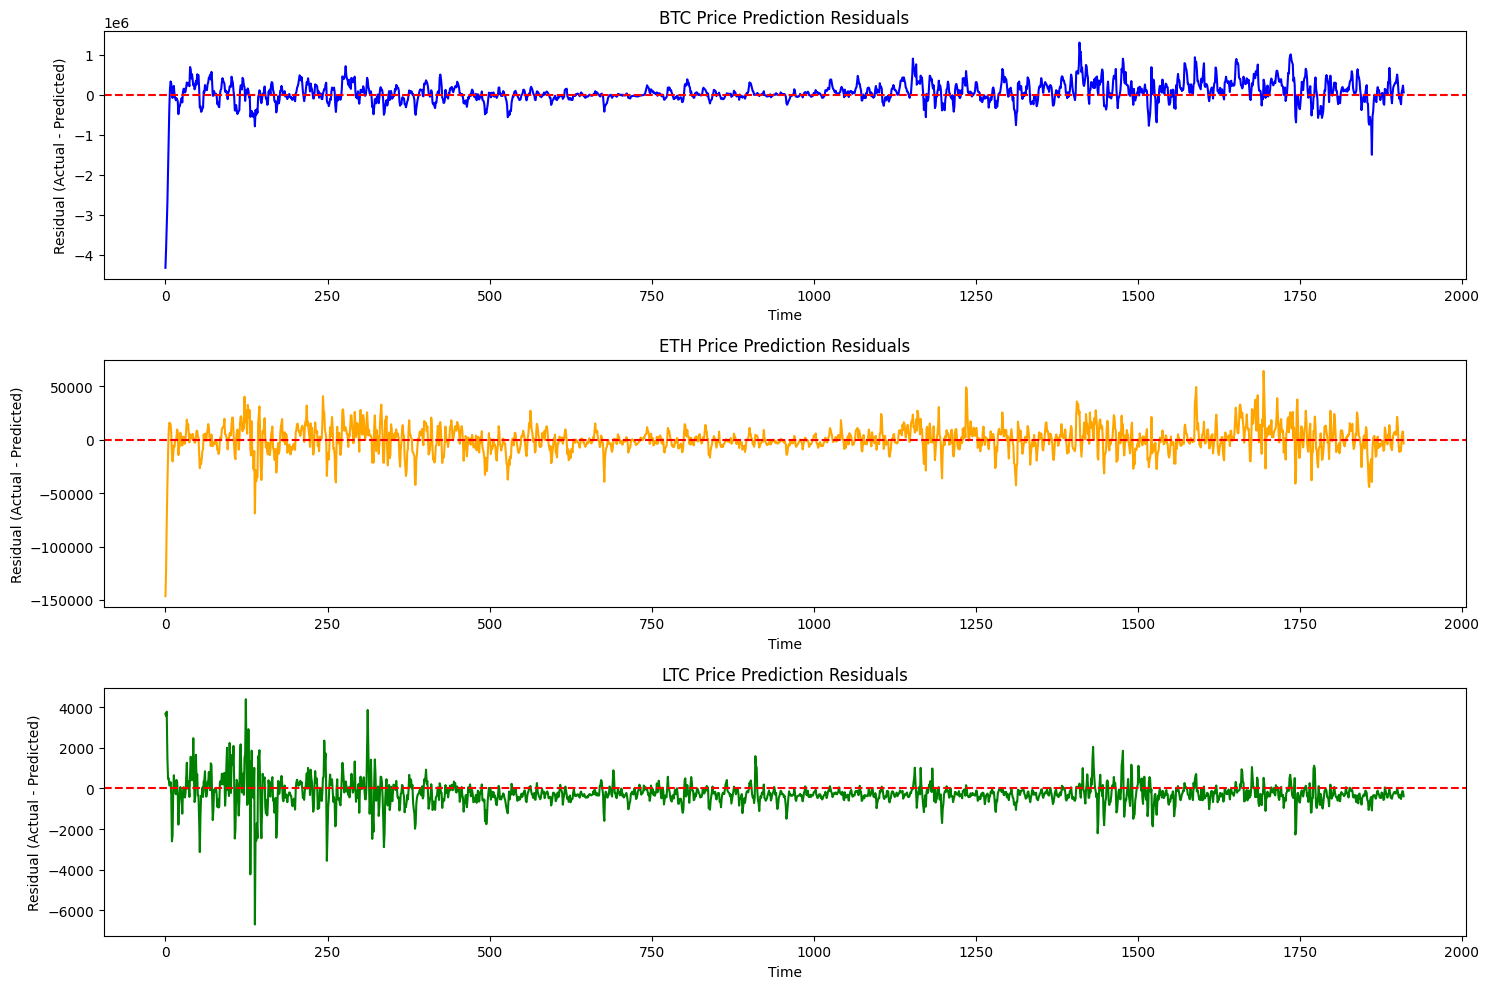

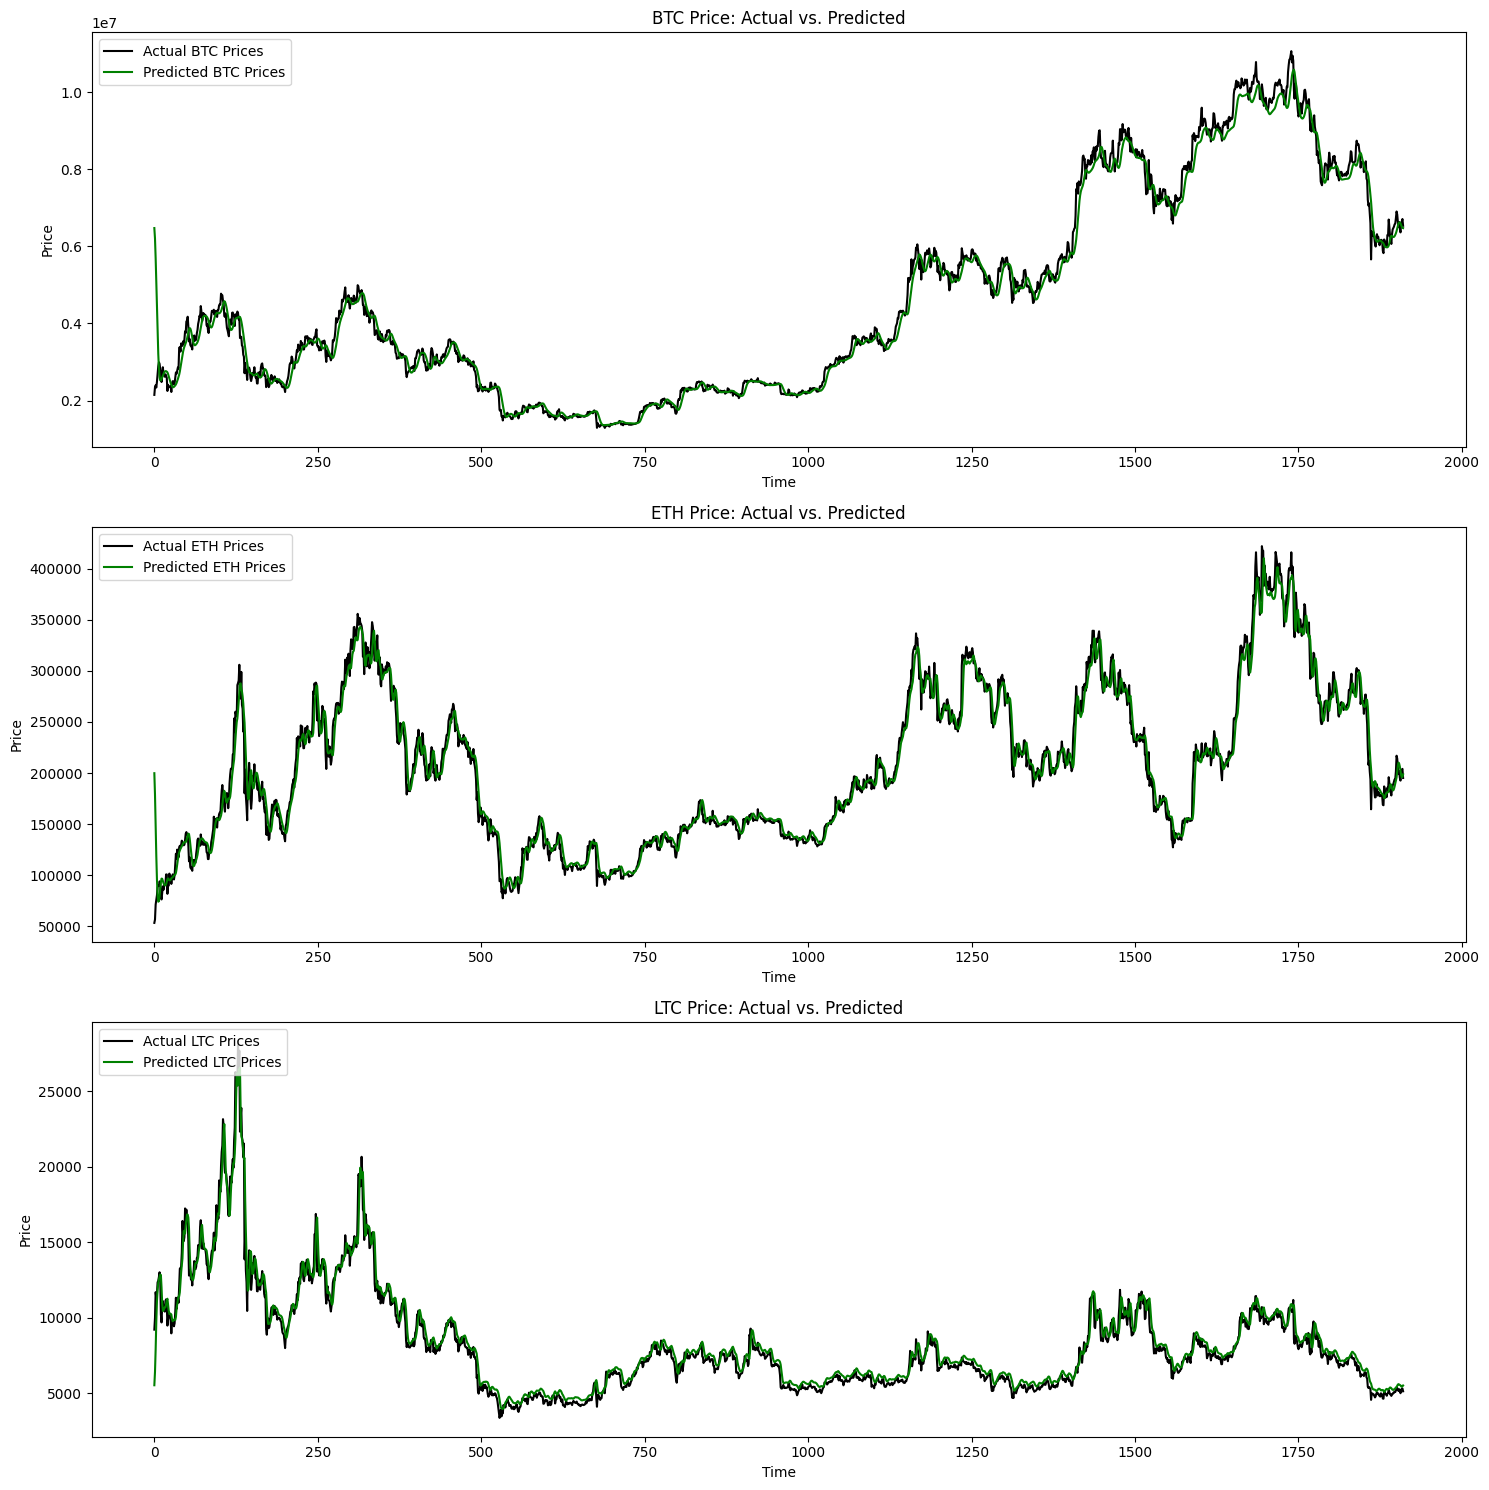

In [26]:
import matplotlib.pyplot as plt

# Residual Plots
plt.figure(figsize=(15, 10))

# BTC Residuals
plt.subplot(3, 1, 1)
residuals_btc = actual_prices_btc.flatten() - prediction_prices_btc.flatten()
plt.plot(residuals_btc, color='blue')
plt.title('BTC Price Prediction Residuals')
plt.xlabel('Time')
plt.ylabel('Residual (Actual - Predicted)')
plt.axhline(0, color='red', linestyle='--')

# ETH Residuals
plt.subplot(3, 1, 2)
residuals_eth = actual_prices_eth.flatten() - prediction_prices_eth.flatten()
plt.plot(residuals_eth, color='orange')
plt.title('ETH Price Prediction Residuals')
plt.xlabel('Time')
plt.ylabel('Residual (Actual - Predicted)')
plt.axhline(0, color='red', linestyle='--')

# LTC Residuals
plt.subplot(3, 1, 3)
residuals_ltc = actual_prices_ltc.flatten() - prediction_prices_ltc.flatten()
plt.plot(residuals_ltc, color='green')
plt.title('LTC Price Prediction Residuals')
plt.xlabel('Time')
plt.ylabel('Residual (Actual - Predicted)')
plt.axhline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

# Combined Actual vs. Predicted Plots
plt.figure(figsize=(15, 15))

# BTC
plt.subplot(3, 1, 1)
plt.plot(actual_prices_btc, color='black', label='Actual BTC Prices')
plt.plot(prediction_prices_btc, color='green', label='Predicted BTC Prices')
plt.title('BTC Price: Actual vs. Predicted')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend(loc='upper left')

# ETH
plt.subplot(3, 1, 2)
plt.plot(actual_prices_eth, color='black', label='Actual ETH Prices')
plt.plot(prediction_prices_eth, color='green', label='Predicted ETH Prices')
plt.title('ETH Price: Actual vs. Predicted')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend(loc='upper left')

# LTC
plt.subplot(3, 1, 3)
plt.plot(actual_prices_ltc, color='black', label='Actual LTC Prices')
plt.plot(prediction_prices_ltc, color='green', label='Predicted LTC Prices')
plt.title('LTC Price: Actual vs. Predicted')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

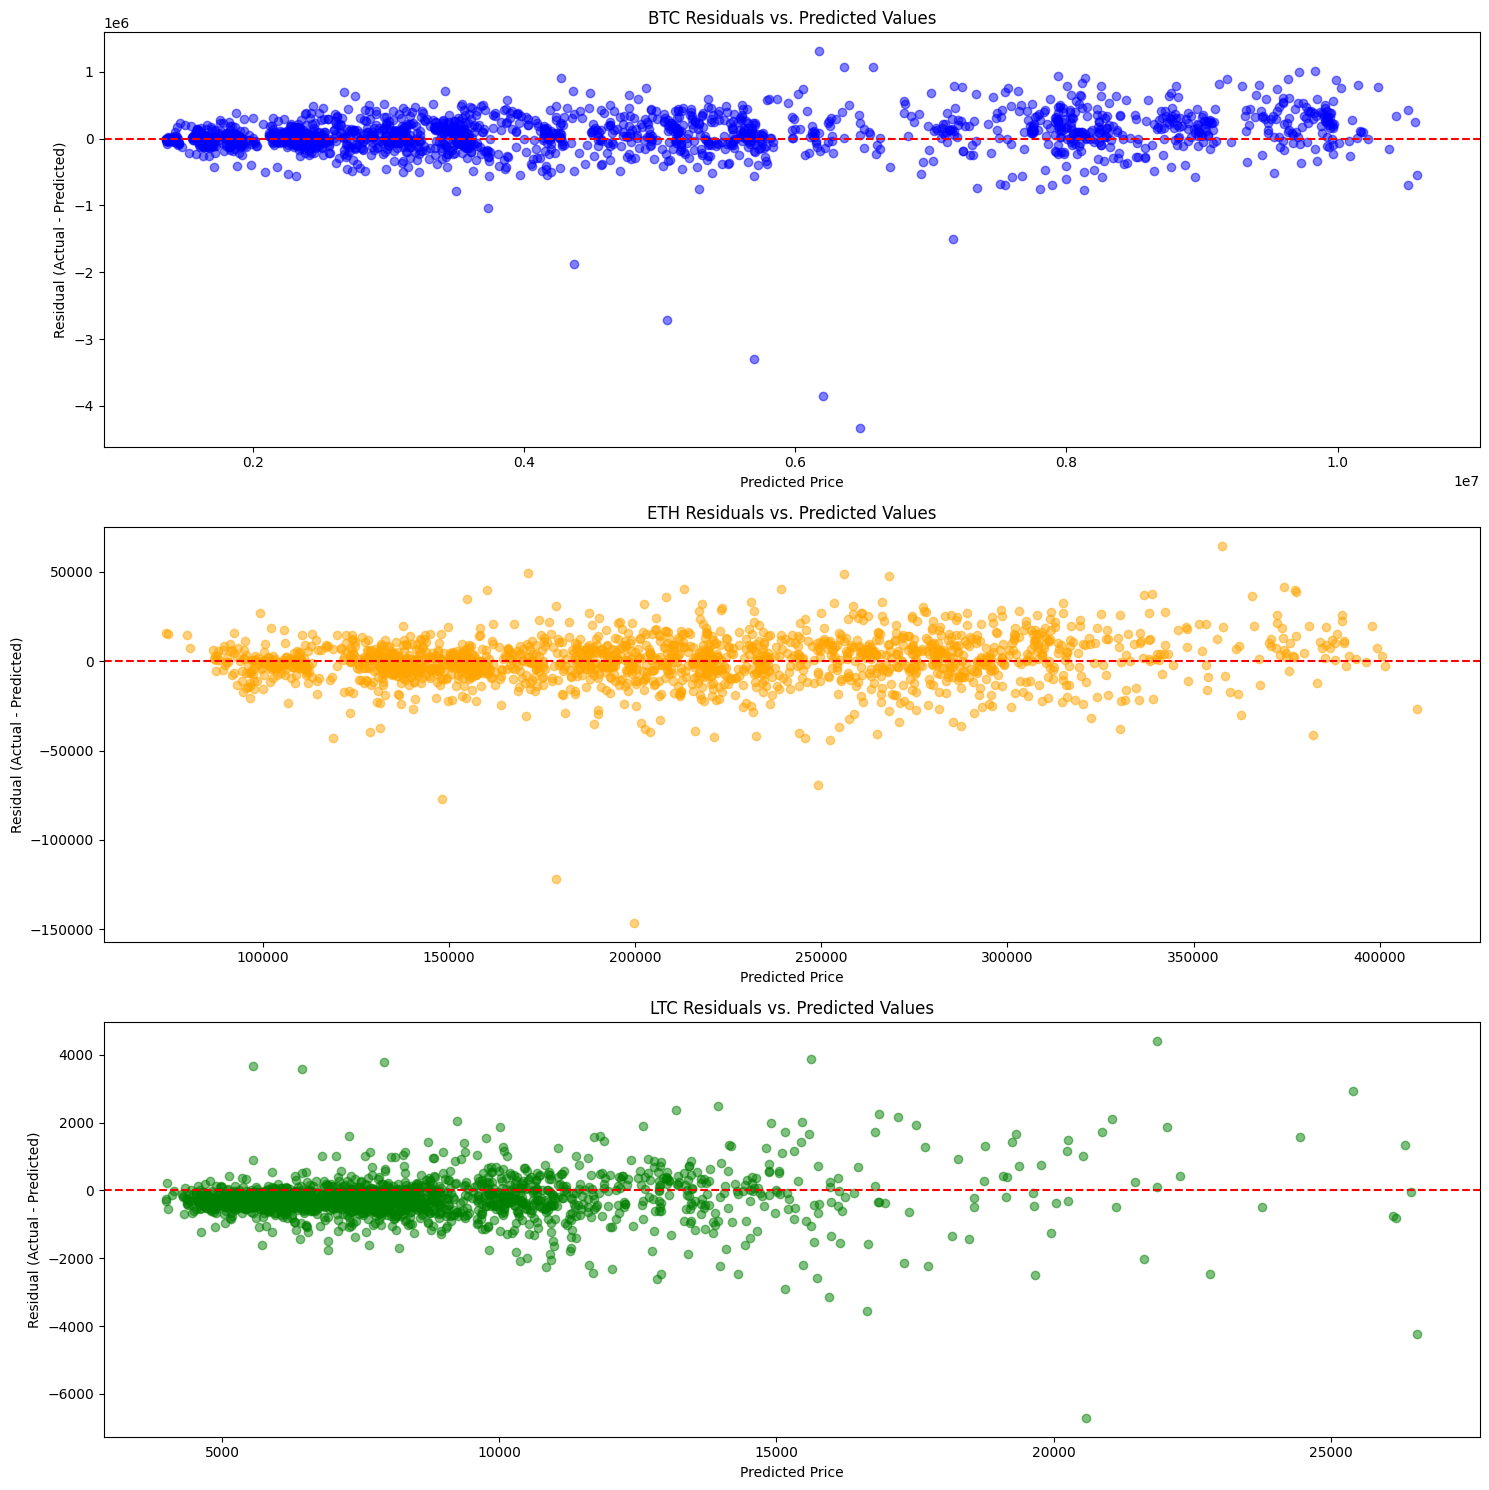

In [28]:
import matplotlib.pyplot as plt

# Scatter plots for residuals vs predicted values
plt.figure(figsize=(15, 15))

# BTC Residuals vs Predicted
plt.subplot(3, 1, 1)
plt.scatter(prediction_prices_btc, residuals_btc, alpha=0.5, color='blue')
plt.title('BTC Residuals vs. Predicted Values')
plt.xlabel('Predicted Price')
plt.ylabel('Residual (Actual - Predicted)')
plt.axhline(0, color='red', linestyle='--')

# ETH Residuals vs Predicted
plt.subplot(3, 1, 2)
plt.scatter(prediction_prices_eth, residuals_eth, alpha=0.5, color='orange')
plt.title('ETH Residuals vs. Predicted Values')
plt.xlabel('Predicted Price')
plt.ylabel('Residual (Actual - Predicted)')
plt.axhline(0, color='red', linestyle='--')

# LTC Residuals vs Predicted
plt.subplot(3, 1, 3)
plt.scatter(prediction_prices_ltc, residuals_ltc, alpha=0.5, color='green')
plt.title('LTC Residuals vs. Predicted Values')
plt.xlabel('Predicted Price')
plt.ylabel('Residual (Actual - Predicted)')
plt.axhline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

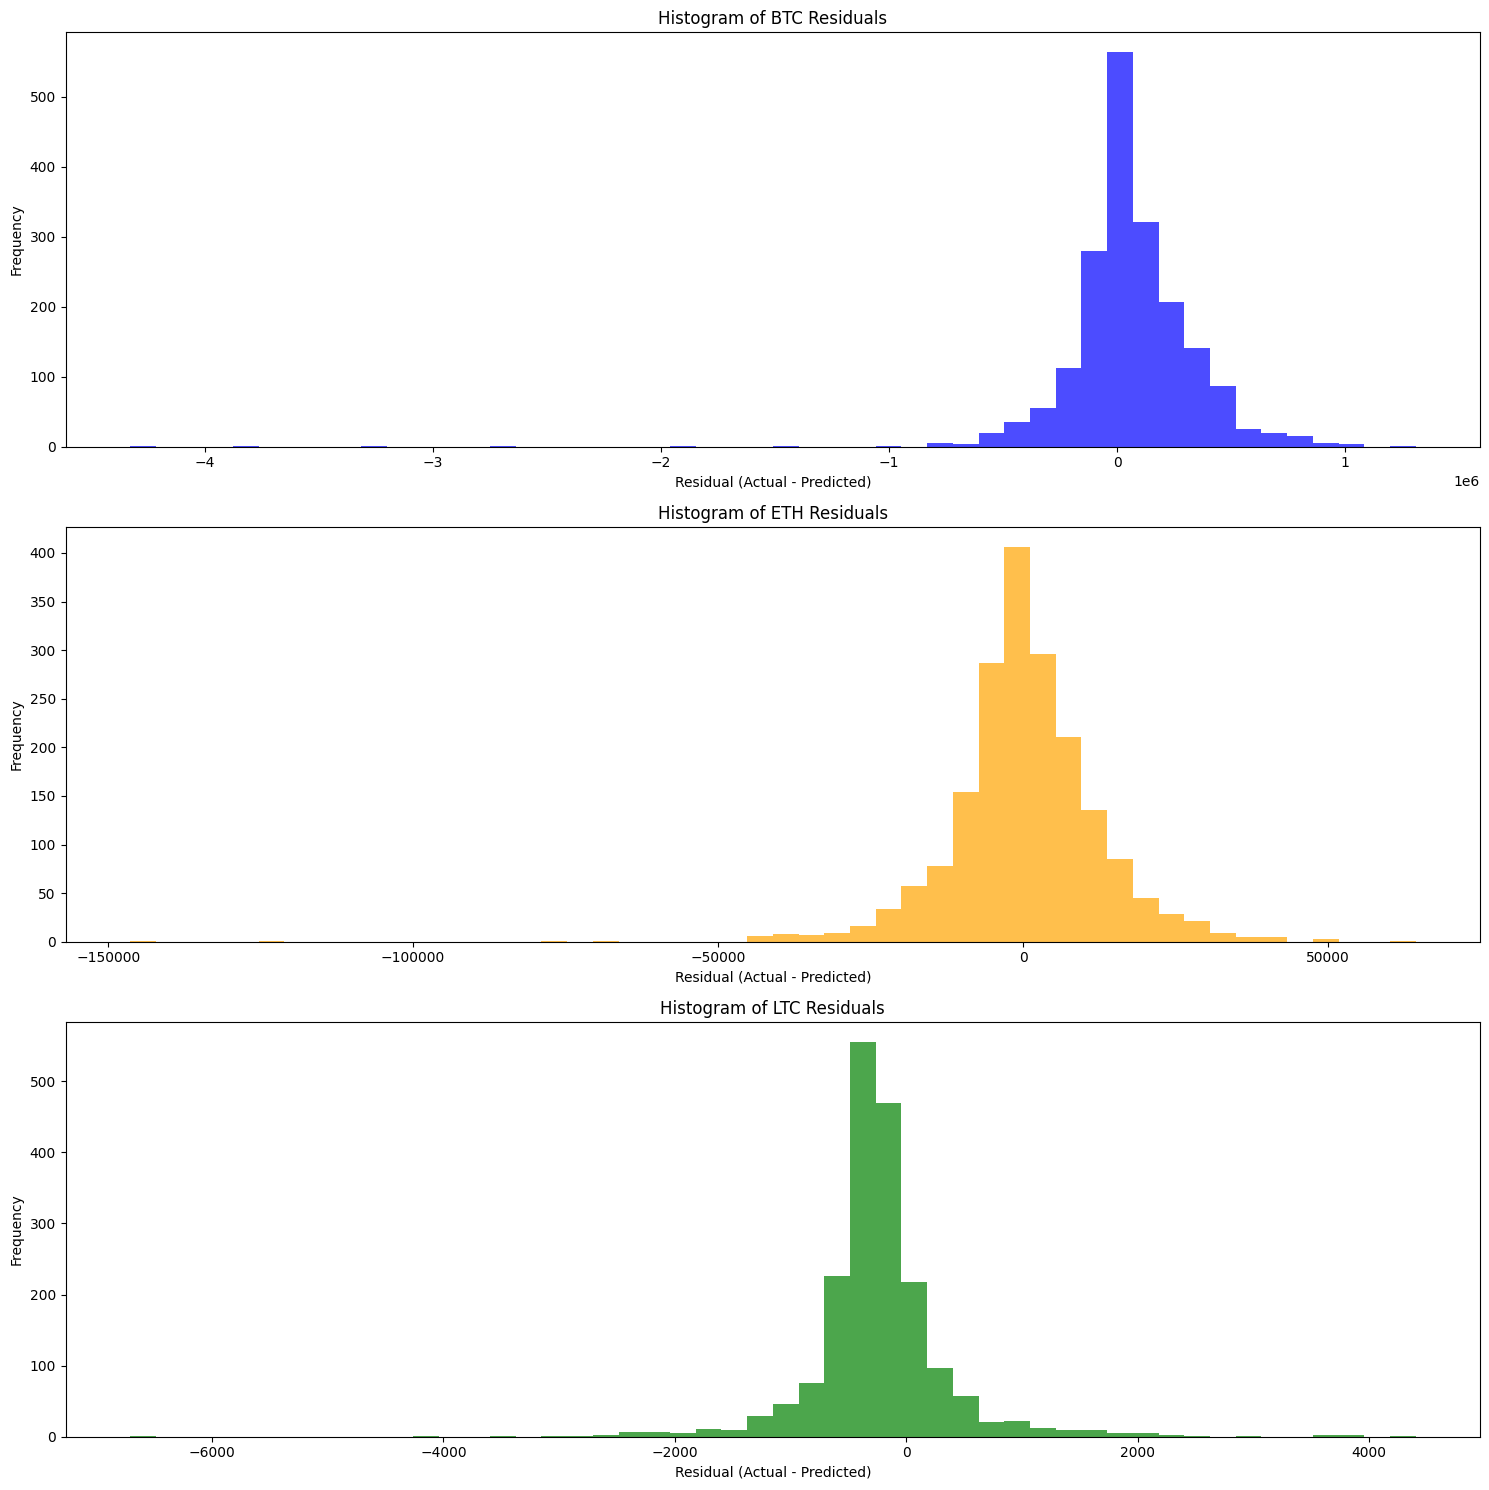

In [29]:
import matplotlib.pyplot as plt

# Histograms for residuals
plt.figure(figsize=(15, 15))

# BTC Residuals Histogram
plt.subplot(3, 1, 1)
plt.hist(residuals_btc, bins=50, color='blue', alpha=0.7)
plt.title('Histogram of BTC Residuals')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')

# ETH Residuals Histogram
plt.subplot(3, 1, 2)
plt.hist(residuals_eth, bins=50, color='orange', alpha=0.7)
plt.title('Histogram of ETH Residuals')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')

# LTC Residuals Histogram
plt.subplot(3, 1, 3)
plt.hist(residuals_ltc, bins=50, color='green', alpha=0.7)
plt.title('Histogram of LTC Residuals')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [18]:
amount = np.float64(input("Enter the amount: "))

if sides1[0] < 0:
  sides1[0] = 0

if sides2[0] < 0:
  sides2[0] = 0

if sides3[0] < 0:
  sides3[0] = 0

if sides1[0] == 0 and sides2[0] == 0 and sides3[0] == 0:
  print("This is not the right time to invest! All the cryptocurrencies are going in loss. You might suffer a low of (upper limit): {}% !!!".format(sides1[1] + sides2[1] + sides3[1]))

else:
  BTC_share = amount*(sides1[0]/(sides1[0] + sides2[0] + sides3[0]))
  BTC_upside = (BTC_share*sides1[0])/100
  BTC_downside = (BTC_share*sides1[1])/100

  ETH_share = amount*(sides2[0]/(sides1[0] + sides2[0] + sides3[0]))
  ETH_upside = (ETH_share*sides2[0])/100
  ETH_downside = (ETH_share*sides2[1])/100

  LTC_share = amount*(sides3[0]/(sides1[0] + sides2[0] + sides3[0]))
  LTC_upside = (LTC_share*sides3[0])/100
  LTC_downside = (LTC_share*sides3[1])/100

  total_upside = BTC_upside + ETH_upside + LTC_upside
  total_downside = BTC_downside + ETH_downside + LTC_downside

  BTC_share = round(BTC_share, 2)
  ETH_share = round(ETH_share, 2)
  LTC_share = round(LTC_share, 2)

  print("You should invest\n {} {} in {}\n {} {} in {}\n {} {} in {} \nFor an upside of {}% and downside of {}% !".format(
                                                                        against_currency, BTC_share, crypto_currency1,
                                                                        against_currency, ETH_share, crypto_currency2,
                                                                        against_currency, LTC_share, crypto_currency3,
                                                                        round((total_upside/amount) * 100, 2),
                                                                        round((total_downside/amount) * 100, 2)))

Enter the amount: 75000
You should invest
 INR 7520.11 in BTC
 INR 55136.58 in ETH
 INR 12343.3 in LTC 
For an upside of 1.25% and downside of 0.18% !
